In [1]:
import caiman as cm
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg as la

ImportError: dlopen(/opt/miniconda3/envs/caiman_env/lib/python3.10/site-packages/cv2.cpython-310-darwin.so, 0x0002): Symbol not found: __ZN6google8protobuf8internal15ThreadSafeArena12thread_cacheEv
  Referenced from: <66D4CB7A-BE1F-360E-B5F0-8A9AC2BBDBE0> /opt/miniconda3/envs/caiman_env/lib/libopencv_dnn.4.13.0.dylib
  Expected in:     <136209F4-74D0-3EBC-8F3E-1CC2A86B4A40> /opt/miniconda3/envs/caiman_env/lib/libprotobuf.33.5.0.dylib

Checking Matrix Size

In [12]:
C_big = cm.source_extraction.cnmf.cnmf.load_CNMF('/Users/josieallred/Research/experiment_analysis/data/downloaded_data/est_allavi1_sc.hdf5').estimates.C
C_1 = cm.source_extraction.cnmf.cnmf.load_CNMF('/Users/josieallred/Research/experiment_analysis/data/downloaded_data/est_avi1_sc.hdf5').estimates.C
C_12 = cm.source_extraction.cnmf.cnmf.load_CNMF('/Users/josieallred/Research/experiment_analysis/data/downloaded_data/estimates_twofiles.hdf5').estimates.C
C_345 = cm.source_extraction.cnmf.cnmf.load_CNMF('/Users/josieallred/Research/experiment_analysis/data/downloaded_data/estimates_345.hdf5').estimates.C

In [13]:
print(f'C for 1 avi shape:{C_1.shape}')
print(f'C for 2 avis shape: {C_12.shape}')
print(f'C for all 3 avis supposedly: {C_345.shape}')

C for 1 avi shape:(7, 1000)
C for 2 avis shape: (7, 1000)
C for all 3 avis supposedly: (42, 3000)


## Experiment 96 - avi.0

In [16]:
# path to daved data
estimates1_path = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706B/2023_09_01/15_04_11/saved_movies/estimates.hdf5'

In [17]:
# extract cnmf estimates
cnmf_obj = cm.source_extraction.cnmf.cnmf.load_CNMF(estimates1_path)
est = cnmf_obj.estimates
C = est.C
np.save('C_exp96_avi0.py', C)

Text(0.5, 1.0, 'avi.0, total neurons: 7')

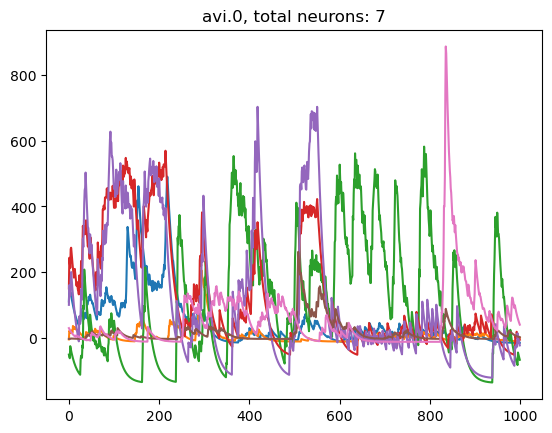

In [18]:
# plot all neurons
for row in C:
    plt.plot(row)
plt.title(f'avi.0, total neurons: {C.shape[0]}')

## time series

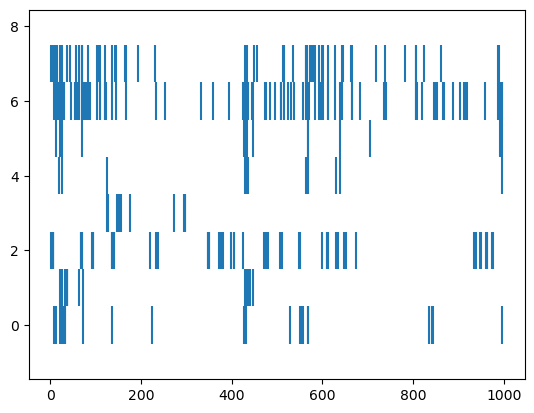

In [33]:
# plot time series data - a row for each neuron and its firing times
C_diff = C[:, 1:] - C[:, :-1]
C_fires = C_diff > 20

event_times = [np.where(row == 1)[0] for row in C_fires]
plt.eventplot(event_times)

# Experiment 96 - avi.25

In [29]:
# upload data and extract estimates
estimates2_path = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706B/2023_09_01/15_04_11/saved_movies/estimates25.hdf5'
cnmf_obj = cm.source_extraction.cnmf.cnmf.load_CNMF(estimates2_path)
est = cnmf_obj.estimates
C = est.C
np.save('C_exp96_avi25.py', C)

Text(0.5, 1.0, 'avi.25, total neurons: 8')

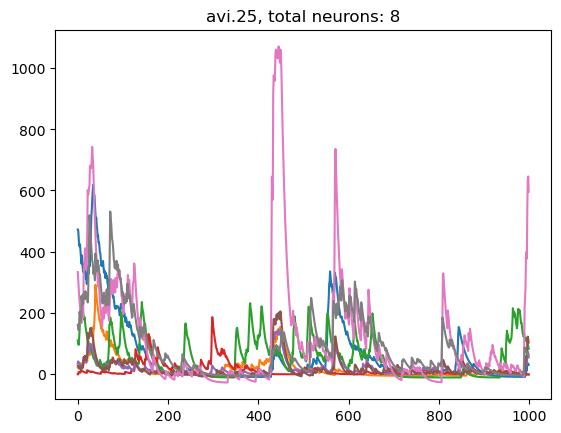

In [30]:
# plot all neurons
C_25 = C
for row in C:
    plt.plot(row)
plt.title(f'avi.25, total neurons: {C.shape[0]}')

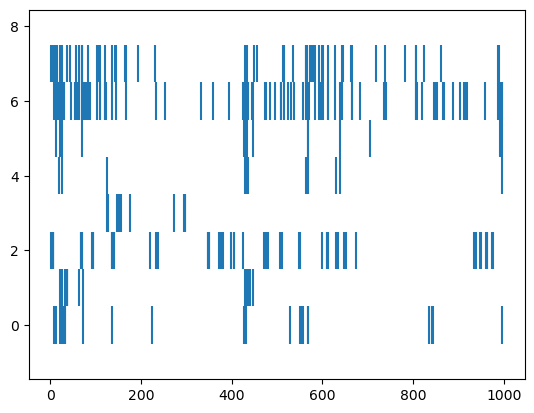

In [34]:
# plot time series data - a row for each neuron and its firing times
C_diff = C_25[:, 1:] - C_25[:, :-1]
C_fires = C_diff > 20

event_times = [np.where(row == 1)[0] for row in C_fires]
plt.eventplot(event_times)

# Experiment 96 - avi.50

In [36]:
estimates3_path = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706B/2023_09_01/15_04_11/saved_movies/estimates50.hdf5'

In [37]:
# extract data ad estimates
cnmf_obj = cm.source_extraction.cnmf.cnmf.load_CNMF(estimates3_path)
est = cnmf_obj.estimates
C = est.C
np.save('C_exp96_avi50.npy', C)

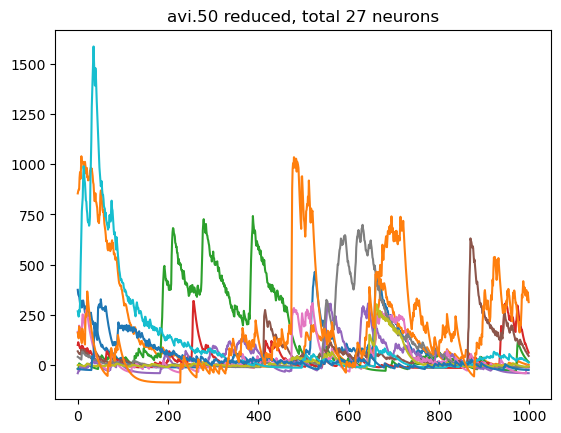

In [38]:
# plot all neurons
for row in C:
    if np.max(row) > 300:
        plt.plot(row)
plt.title(f'avi.50 reduced, total {C.shape[0]} neurons')
C_50 = C

## time series

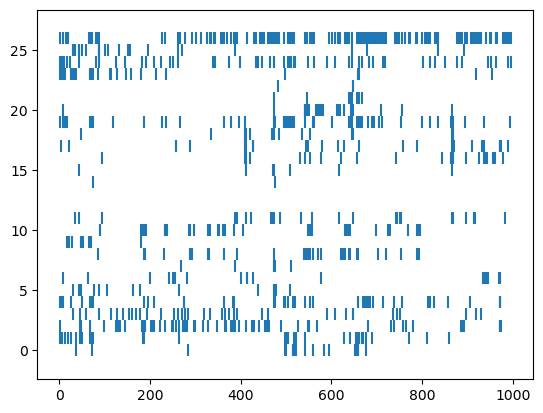

In [39]:
# plot time series
C_diff = C_50[:, 1:] - C_50[:, :-1]
C_fires = C_diff > 20

event_times = [np.where(row == 1)[0] for row in C_fires]
plt.eventplot(event_times)

# Experiment 96 - avi.75

In [32]:
estimates3_path = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/saved_movies/estimates75.hdf5'

In [28]:
cnmf_obj = cm.source_extraction.cnmf.cnmf.load_CNMF(estimates3_path)
est = cnmf_obj.estimates
C = est.C
np.save('C_exp96_avi75.py', C)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/saved_movies/estimates75.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Text(0.5, 1.0, 'avi.75 reduced, total neurons: 7')

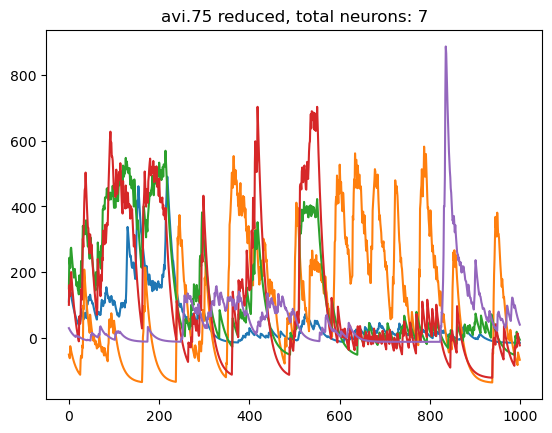

In [ ]:
C_75 = C
for row in C:
    if np.max(row) > 300:
        plt.plot(row)
plt.title(f'avi.75 reduced, total neurons: {C.shape[0]}')

# PCA exploration

(7, 999)
(27, 999)


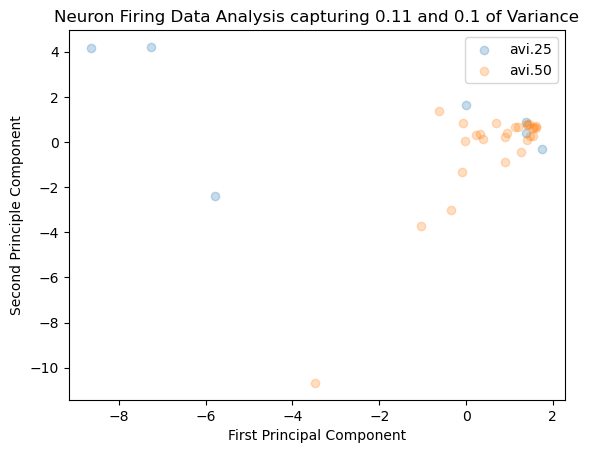

In [ ]:
C_25_diff = C_25[:, 1:] - C_25[:, :-1]
C_25_fires = C_25_diff > 12
print(C_25_fires.shape)

C_50_diff = C_50[:, 1:] - C_50[:, :-1]
C_50_fires = C_50_diff > 12
print(C_50_fires.shape)

X = np.vstack((C_25_fires, C_50_fires))

Y = X - np.mean(X, axis=0)
U, sv, V = la.svd(Y)

Y_hat = Y @ V.T[:, :2]

# do variance analysis
variances = [i ** 2 / np.sum(sv ** 2) for i in sv]
c1_prop = round(variances[0] / np.sum(variances), 2)
c2_prop = round(variances[1] / np.sum(variances), 2)

scores_25 = Y_hat[:7, :]
scores_75 = Y_hat[7:, :]

plt.scatter(scores_25[:, 0], scores_25[:, 1], label="avi.25", alpha=0.25)
plt.scatter(scores_75[:, 0], scores_75[:, 1], label="avi.50", alpha=0.25)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principle Component")
plt.title(f"Neuron Firing Data Analysis capturing {c1_prop} and {c2_prop} of Variance")
plt.legend()
plt.show()